# TASKS

In [2]:
#Train SVM on Breast Cancer Dataset (Linear & RBF Kernel)
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- Linear Kernel ----------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)

print("Linear SVM Accuracy:",
      accuracy_score(y_test, pred_linear))

# ---------------- RBF Kernel ----------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

pred_rbf = svm_rbf.predict(X_test)

print("RBF SVM Accuracy:",
      accuracy_score(y_test, pred_rbf))

Linear SVM Accuracy: 0.956140350877193
RBF SVM Accuracy: 0.9473684210526315


In [3]:
#Train KNN with K = 3, 5, 7 and Compare Accuracy
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in [3, 5, 7]:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    prediction = knn.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print(f"K = {k}  Accuracy = {accuracy:.4f}")

K = 3  Accuracy = 0.9298
K = 5  Accuracy = 0.9561
K = 7  Accuracy = 0.9561


In [5]:
#Perform 5-Fold Cross Validation
from sklearn.model_selection import cross_val_score

# Linear SVM
linear_scores = cross_val_score(
    svm_linear,
    X,
    y,
    cv=5
)

print("\nLinear SVM Cross Validation Scores:")
print(linear_scores)
print("Average Accuracy:",
      linear_scores.mean())

# RBF SVM
rbf_scores = cross_val_score(
    svm_rbf,
    X,
    y,
    cv=5
)

print("\nRBF SVM Cross Validation Scores:")
print(rbf_scores)
print("Average Accuracy:",
      rbf_scores.mean())

# KNN (K=5)
knn = KNeighborsClassifier(n_neighbors=5)

knn_scores = cross_val_score(
    knn,
    X,
    y,
    cv=5
)

print("\nKNN Cross Validation Scores:")
print(knn_scores)
print("Average Accuracy:",
      knn_scores.mean())


Linear SVM Cross Validation Scores:
[0.94736842 0.92982456 0.97368421 0.92105263 0.95575221]
Average Accuracy: 0.9455364073901569

RBF SVM Cross Validation Scores:
[0.85087719 0.89473684 0.92982456 0.94736842 0.9380531 ]
Average Accuracy: 0.9121720229777983

KNN Cross Validation Scores:
[0.88596491 0.93859649 0.93859649 0.94736842 0.92920354]
Average Accuracy: 0.9279459711224964


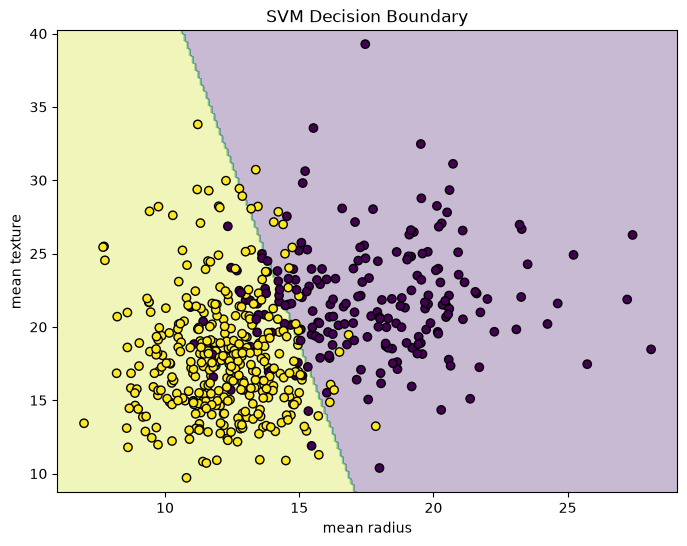

In [7]:
#Plot Decision Boundary (Using Only Two Features)
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC

# Load dataset
data = load_breast_cancer()

# Use only first two features
X = data.data[:, :2]
y = data.target

# Train model
model = SVC(kernel='linear')
model.fit(X, y)

# Create mesh grid
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])

plt.title("SVM Decision Boundary")

plt.show()

# PRACTICE

In [9]:
#Handwritten Digit Classification using KNN (MNIST Subset)
#  Import libraries
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load handwritten digits dataset
digits = load_digits()

X = digits.data
y = digits.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9833333333333333

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.97      0.98        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


Confusion Matrix
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  

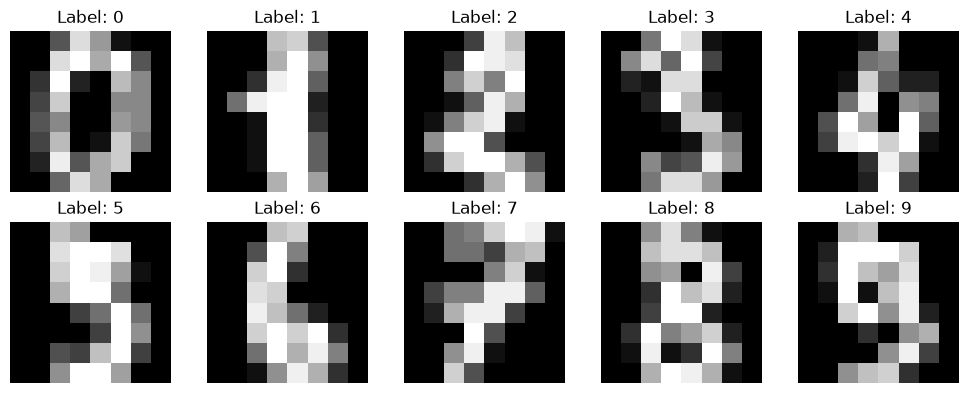

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title("Label: " + str(digits.target[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
#Compare SVM Kernels (Linear, Polynomial, RBF)
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
digits = load_digits()

X = digits.data
y = digits.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

kernels = ["linear", "poly", "rbf"]

print("Kernel Comparison\n")

for kernel in kernels:

    model = SVC(kernel=kernel)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    print(kernel.upper(), "Kernel Accuracy:", round(accuracy,4))

Kernel Comparison

LINEAR Kernel Accuracy: 0.9778
POLY Kernel Accuracy: 0.9917
RBF Kernel Accuracy: 0.9861


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM Linear": SVC(kernel="linear"),
    "SVM Polynomial": SVC(kernel="poly"),
    "SVM RBF": SVC(kernel="rbf")
}

print("Model Comparison\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(name, ":", round(acc,4))

Model Comparison

KNN : 0.9833
SVM Linear : 0.9778
SVM Polynomial : 0.9917
SVM RBF : 0.9861
